# Outlier Patch Detection with NaturalSpice

This notebook demonstrates a test for detecting a 'bad' patch of sky using the naturalspice
unmixing method. We:

1. Generate a fake shear map on a **1000 sq deg rectangular footprint**
2. Divide the footprint into **10 equal-area patches**
3. Replace **one patch** with a shear map drawn from a different (higher-amplitude) cosmology
4. Measure the **angular power spectrum** in each patch
5. Apply the **naturalspice** unmixing to correct for masking effects
6. **Plot all 10 Cls** overlaid — the bad patch should stand out clearly

In [2]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import camb
from camb.sources import SplinedSourceWindow
import skysegmentor

import heracles
import heracles.healpy
from heracles.core import update_metadata

# --- Survey / resolution parameters ---
nside     = 1024   # HEALPix resolution parameter
lmax_data = 1500   # Max multipole for shear maps
lmax_mask = 3000   # Max multipole for mask maps (2x for naturalspice accuracy)
lmin      = 100    # Min multipole for power spectrum estimation
n_patches = 20    # Number of equal-area patches
bad_patch = 4     # Zero-indexed patch that gets the wrong cosmology

npix = hp.nside2npix(nside)
print(f"nside={nside}, npix={npix:,}")
print(f"Pixel area: {hp.nside2pixarea(nside, degrees=True):.5f} sq deg")

nside=1024, npix=12,582,912
Pixel area: 0.00328 sq deg


## 1. Theory power spectra

We define two cosmologies:
- **Fiducial** (9 patches): Planck-like parameters with $A_s = 2.1 \times 10^{-9}$
- **Bad** (1 patch): Same geometry but $A_s = 8.4 \times 10^{-9}$ (4× primordial amplitude → ~4× in $C_\ell^{EE}$)

We use a single lensing source with a Gaussian $n(z)$ centred at $z=0.8$.

In [3]:
# Shared redshift distribution
z  = np.linspace(0.0, 3.0, 200)
nz = np.exp(-0.5 * ((z - 0.8) / 0.3) ** 2)
nz /= np.trapz(nz, z)

# Convergence → shear conversion factor
ell_arr = np.arange(lmax_data + 1)
fl = -np.sqrt((ell_arr + 2) * (ell_arr + 1) * ell_arr * (ell_arr - 1))
fl /= np.clip(ell_arr * (ell_arr + 1), 1, None)


def shear_cls_from_camb(As, lmax):
    """Return shear EE Cl array [0..lmax] for a given primordial amplitude."""
    pars = camb.set_params(
        H0=67.0, omch2=0.12, ombh2=0.022,
        As=As, ns=0.96,
        NonLinear=camb.model.NonLinear_both,
    )
    pars.Want_CMB = False
    pars.min_l   = 1
    pars.set_for_lmax(2 * lmax)
    pars.SourceWindows = [SplinedSourceWindow(source_type="lensing", z=z, W=nz)]

    res      = camb.get_results(pars)
    cls_camb = res.get_source_cls_dict(lmax=lmax, raw_cl=True)

    ell_loc  = np.arange(lmax + 1)
    fl_loc   = -np.sqrt((ell_loc + 2) * (ell_loc + 1) * ell_loc * (ell_loc - 1))
    fl_loc  /= np.clip(ell_loc * (ell_loc + 1), 1, None)
    return fl_loc**2 * cls_camb["W1xW1"][: lmax + 1]


print("Computing fiducial Cls...")
cl_EE_fid = shear_cls_from_camb(As=2.1e-9, lmax=lmax_data)

print("Computing 'bad' cosmology Cls...")
cl_EE_bad = shear_cls_from_camb(As=8.4e-9, lmax=lmax_data)  # 4x amplitude

print(f"\nCl_bad / Cl_fid at l=100: {cl_EE_bad[100] / cl_EE_fid[100]:.2f}")

Computing fiducial Cls...


/tmp/ipykernel_23273/1183994370.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz /= np.trapz(nz, z)


Computing 'bad' cosmology Cls...

Cl_bad / Cl_fid at l=100: 4.08


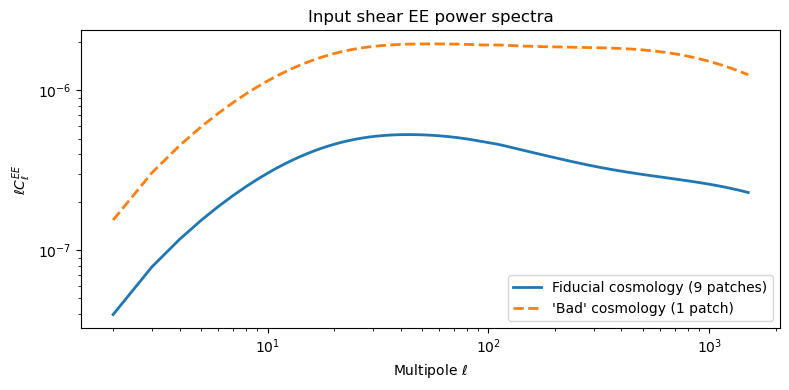

In [4]:
import os
PLOT_DIR = os.path.join(os.path.dirname(os.path.abspath("outlier_patch_test.ipynb")), "..", "paper", "paper_plots")
os.makedirs(PLOT_DIR, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 4))
fac = ell_arr[2:] 
ax.plot(ell_arr[2:], fac * cl_EE_fid[2:], lw=2, color="C0",
        label="Fiducial cosmology (9 patches)")
ax.plot(ell_arr[2:], fac * cl_EE_bad[2:], lw=2, color="C1", ls="--",
        label="'Bad' cosmology (1 patch)")
ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(r"$\ell C_\ell^{EE}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.set_title("Input shear EE power spectra")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fig1_theory_cls.pdf"), bbox_inches="tight")
plt.show()

## 2. Generate full-sky shear maps

We generate spin-2 (Q, U) shear maps using `hp.synalm` + `hp.alm2map`:
- **Fiducial map**: one full-sky realisation used for 9 patches
- **Bad map**: independent realisation drawn from the high-amplitude cosmology

In [5]:
np.random.seed(42)
alm_E_fid = hp.synalm(cl_EE_fid, lmax=lmax_data, new=True)
alm_zero  = np.zeros(hp.Alm.getsize(lmax_data), dtype=np.complex128)
_, Q_fid, U_fid = hp.alm2map(
    [alm_zero, alm_E_fid, np.zeros_like(alm_E_fid)],
    nside=nside, lmax=lmax_data,
)

np.random.seed(137)
alm_E_bad = hp.synalm(cl_EE_bad, lmax=lmax_data, new=True)
_, Q_bad, U_bad = hp.alm2map(
    [np.zeros_like(alm_E_bad), alm_E_bad, np.zeros_like(alm_E_bad)],
    nside=nside, lmax=lmax_data,
)

print(f"Fiducial shear RMS : {np.std(Q_fid):.5f}")
print(f"'Bad'   shear RMS  : {np.std(Q_bad):.5f}")
print(f"RMS ratio          : {np.std(Q_bad) / np.std(Q_fid):.2f}")

Fiducial shear RMS : 0.00597
'Bad'   shear RMS  : 0.01394
RMS ratio          : 2.33


## 3. Define the footprint and 10 patches

We use the real WHT mask from the TR1 SHE-1 map as the survey footprint,
downgraded to nside=1024. The footprint is divided into 10 equal-area patches
using `skysegmentor`.

In [6]:
mask = hp.read_map("/home/jaimerzp/Documents/software/heracles/examples/tr1_data/tr1_mask_nside_2048.fits")
mask = hp.ud_grade(mask, nside_out=nside)
jkmap_patches = skysegmentor.segmentmapN(mask, n_patches)
patches = [jkmap_patches == k for k in range(1, n_patches + 1)]

for i, p in enumerate(patches):
    area = p.sum() * hp.nside2pixarea(nside, degrees=True)
    tag  = "  ← BAD PATCH" if i == bad_patch else ""
    print(f"  Patch {i:2d}: area={area:.0f} sq deg  Npix={p.sum()}{tag}")

  Patch  0: area=19 sq deg  Npix=5780
  Patch  1: area=19 sq deg  Npix=5784
  Patch  2: area=19 sq deg  Npix=5779
  Patch  3: area=19 sq deg  Npix=5768
  Patch  4: area=19 sq deg  Npix=5777  ← BAD PATCH
  Patch  5: area=19 sq deg  Npix=5775
  Patch  6: area=19 sq deg  Npix=5771
  Patch  7: area=19 sq deg  Npix=5778
  Patch  8: area=19 sq deg  Npix=5783
  Patch  9: area=19 sq deg  Npix=5773
  Patch 10: area=19 sq deg  Npix=5787
  Patch 11: area=19 sq deg  Npix=5781
  Patch 12: area=19 sq deg  Npix=5783
  Patch 13: area=19 sq deg  Npix=5775
  Patch 14: area=19 sq deg  Npix=5774
  Patch 15: area=19 sq deg  Npix=5778
  Patch 16: area=19 sq deg  Npix=5769
  Patch 17: area=19 sq deg  Npix=5778
  Patch 18: area=19 sq deg  Npix=5777
  Patch 19: area=19 sq deg  Npix=5779


In [7]:
vis_map = np.where(footprint, jkmap_patches.astype(float), hp.UNSEEN)
vis_map[patches[bad_patch]] = 0.0   # stand-out colour for bad patch

# Centre gnomview on the footprint
footpix      = np.where(footprint)[0]
vec          = np.mean(np.stack(hp.pix2vec(nside, footpix), axis=1), axis=0)
lon_c, lat_c = hp.vec2ang(vec, lonlat=True)
lon_c, lat_c = float(lon_c), float(lat_c)

hp.mollview(
    vis_map,
    rot=(lon_c, lat_c, 0), 
    title=f"TR1 footprint — {n_patches} patches (patch {bad_patch} = bad cosmology)",
    cmap="tab10", notext=True,
)
hp.graticule(dpar=5, dmer=5, alpha=0.3)
plt.savefig(os.path.join(PLOT_DIR, "fig2_patch_map.pdf"), bbox_inches="tight")
plt.show()

NameError: name 'footprint' is not defined

## 4. Heracles setup

We need two mappers: one for the shear data (`lmax_data = 300`) and one for the
mask maps (`lmax_mask = 600`). The higher mask `lmax` improves the accuracy of the
real-space division performed by naturalspice.

In [ ]:
mapper      = heracles.healpy.HealpixMapper(nside=nside, lmax=lmax_data)
mapper_mask = heracles.healpy.HealpixMapper(nside=nside, lmax=lmax_mask)

# Fields dictionary tells naturalspice that SHE uses WHT as its mask
fields = {
    "SHE": heracles.Shears(mapper,  mask="WHT"),
    "WHT": heracles.Weights(mapper),
}

print(f"Data mapper : nside={mapper.nside}, lmax={mapper.lmax}")
print(f"Mask mapper : nside={mapper_mask.nside}, lmax={mapper_mask.lmax}")

Data mapper : nside=1024, lmax=1500
Mask mapper : nside=1024, lmax=3000


## 5. Compute per-patch pseudo-Cls

For each patch we:
1. Apply the patch mask to the shear map (zero outside the patch)
2. Transform to alms via `mapper.transform()`
3. Compute the pseudo-$C_\ell$ with `heracles.angular_power_spectra()`
4. Do the same for the binary mask map (needed by naturalspice)

In [ ]:
data_cls   = {}
mask_cls   = {}
shear_alms = []   # per-patch alms (needed for full-footprint sum)
mask_alms  = []

for i in range(n_patches):
    Q_src, U_src = (Q_bad, U_bad) if i == bad_patch else (Q_fid, U_fid)

    # 1. Compute alms of each region
    shear_map    = mapper.create(2, spin=2)
    shear_map[0] = np.where(patches[i], Q_src, 0.0)
    shear_map[1] = np.where(patches[i], U_src, 0.0)
    shear_alm    = mapper.transform(shear_map)
    shear_alms.append(shear_alm)

    mask_map             = mapper_mask.create(spin=0)
    mask_map[patches[i]] = 1.0
    mask_alm             = mapper_mask.transform(mask_map)
    mask_alms.append(mask_alm)

    # 2. Compute pseudo-Cls of each region
    data_cls.update(heracles.angular_power_spectra({("SHE", i): shear_alm}))
    mask_cls.update(heracles.angular_power_spectra({("WHT", i): mask_alm}))

    if i % 2 == 0 or i == n_patches - 1:
        print(f"  Processed patch {i}/{n_patches - 1}")

print("\nDone.")

  Processed patch 0/19
  Processed patch 2/19
  Processed patch 4/19
  Processed patch 6/19
  Processed patch 8/19
  Processed patch 10/19
  Processed patch 12/19
  Processed patch 14/19
  Processed patch 16/19
  Processed patch 18/19
  Processed patch 19/19

Done.


## 6. Unmix the Cls of each region

`naturalspice` divides the data correlation function by the mask correlation
function in real space, correcting for mode-mixing without an explicit
mixing-matrix inversion.

In [ ]:
print("Applying naturalspice...")
unmixed_cls = heracles.naturalspice(data_cls, mask_cls, fields, rcond=0.01)
print("Done.")

nlbins = 10
ledges = np.logspace(np.log10(lmin), np.log10(lmax_data), nlbins + 1)

unmixed_binned = heracles.binned(unmixed_cls, ledges)

# Bin the theory predictions for comparison
zeros = np.zeros(lmax_data + 1)

theory_fid = heracles.Result(
    np.array([[cl_EE_fid, zeros], [zeros, zeros]]),
    spin=(2, 2), axis=-1,
)
theory_bad = heracles.Result(
    np.array([[cl_EE_bad, zeros], [zeros, zeros]]),
    spin=(2, 2), axis=-1,
)

theory_fid_b = heracles.binned(theory_fid, ledges)
theory_bad_b = heracles.binned(theory_bad, ledges)

Applying naturalspice...
Done.


## 7. Full-footprint $C_\ell$ and sample covariance

Because the spherical harmonic transform is linear, the full-footprint alm is
simply the sum of the per-region alms — no extra SHT needed.

The covariance is the **sample covariance** of the per-region unmixed Cls:
$$\hat{S}_{ij} = \frac{1}{N-1}\sum_k (C^k_i - \bar{C}_i)(C^k_j - \bar{C}_j)$$
This characterises the region-to-region scatter and is used directly in the
$\chi^2$ test.

In [ ]:
import heracles.dices as dices

# Full-footprint alm = sum of per-patch alms (SHT linearity — no extra SHTs)
alm_full_shear = np.zeros_like(shear_alms[0])
alm_full_mask  = np.zeros_like(mask_alms[0])
for s, m in zip(shear_alms, mask_alms):
    alm_full_shear += s
    alm_full_mask  += m

full_data_cls = heracles.angular_power_spectra({("SHE", "full"): alm_full_shear})
full_mask_cls = heracles.angular_power_spectra({("WHT", "full"): alm_full_mask})

print("Applying naturalspice to full footprint...")
full_unmixed   = heracles.naturalspice(full_data_cls, full_mask_cls, fields, rcond=0.01)
full_unmixed_b = heracles.binned(full_unmixed, ledges)
print("Done.")

KEY        = ("SHE", "SHE", "full", "full")
ell_full   = full_unmixed_b[KEY].ell
fac_full   = ell_full 
cl_full_ee = np.array(full_unmixed_b[KEY][0, 0])
cl_full_bb = np.array(full_unmixed_b[KEY][1, 1])
nlbins     = len(ell_full)

Applying naturalspice to full footprint...
Done.


In [ ]:
# Sample covariance of the per-region unmixed Cls
cls_patches_ee = np.array([
    np.array(unmixed_binned[("SHE", "SHE", i, i)][0, 0])
    for i in range(n_patches)
])
cls_patches_bb = np.array([
    np.array(unmixed_binned[("SHE", "SHE", i, i)][1, 1])
    for i in range(n_patches)
])

cov_ee = np.cov(cls_patches_ee.T)   # shape (nlbins, nlbins)  — per-region scatter
cov_bb = np.cov(cls_patches_bb.T)

# Error on the full-footprint mean = std error of the per-region ensemble
err_ee = np.sqrt(np.diag(cov_ee) / n_patches)
err_bb = np.sqrt(np.diag(cov_bb) / n_patches)

rank_ee = np.linalg.matrix_rank(cov_ee)
print(f"Covariance rank: {rank_ee}  (expected {min(n_patches-1, nlbins)} = min({n_patches}-1, {nlbins}))")

Covariance rank: 10  (expected 10 = min(20-1, 10))


## 8. Plots

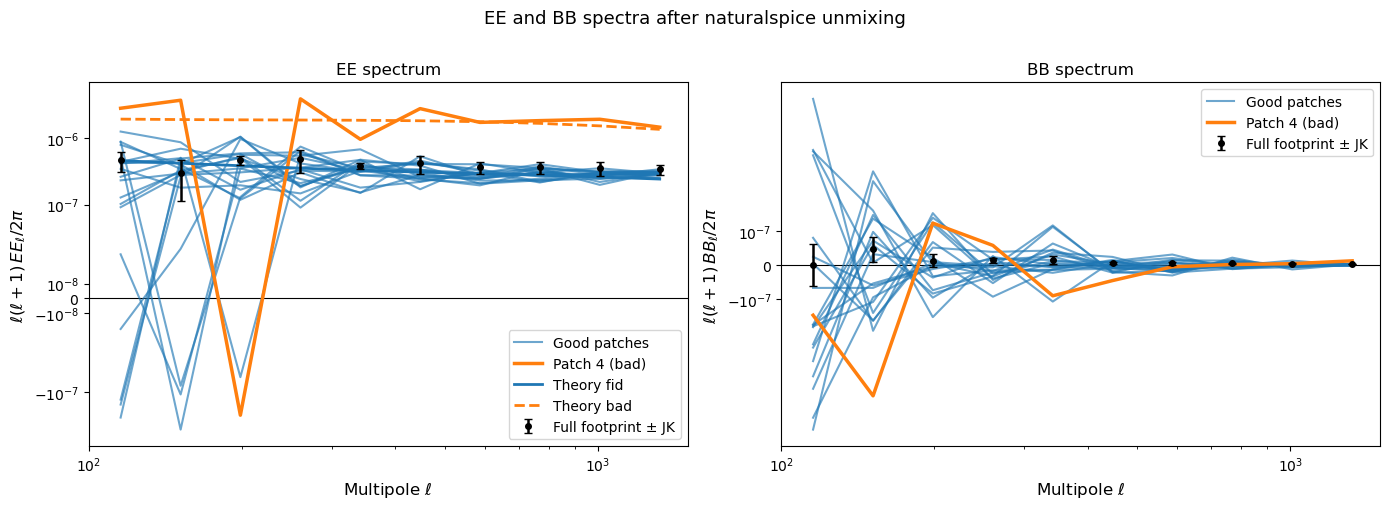

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for component, comp_idx, comp_label, ax in [
    ("EE", (0, 0), r"$C_\ell^{EE}$", axes[0]),
    ("BB", (1, 1), r"$C_\ell^{BB}$", axes[1]),
]:
    for i in range(n_patches):
        cl_res = unmixed_binned[("SHE", "SHE", i, i)]
        ell_b  = cl_res.ell
        cl_comp = cl_res[comp_idx[0], comp_idx[1]]
        factor  = ell_b 

        if i == bad_patch:
            ax.plot(ell_b, factor * cl_comp,
                    color="C1", lw=2.5, zorder=5, label=f"Patch {i} (bad)")
        else:
            label = "Good patches" if i == 0 else None
            ax.plot(ell_b, factor * cl_comp,
                    color="C0", lw=1.5, alpha=0.65, label=label)

    ax.axhline(0, color="k", lw=0.8, zorder=-1)
    ax.set_xlabel(r"Multipole $\ell$", fontsize=12)
    ax.set_ylabel(r"$\ell(\ell+1)\," + component + r"_\ell / 2\pi$", fontsize=12)
    ax.set_xscale("log")
    ax.set_xlim(lmin, lmax_data)
    ax.set_title(f"{component} spectrum", fontsize=12)
    ax.legend(fontsize=10)

# Add fiducial theory to EE panel
ell_th = theory_fid_b.ell
fac_th = ell_th 
axes[0].plot(ell_th, fac_th * theory_fid_b[0, 0], "C0-",  lw=2, label="Theory fid",  zorder=6)
axes[0].plot(ell_th, fac_th * theory_bad_b[0, 0], "C1--", lw=2, label="Theory bad",  zorder=6)
axes[0].set_yscale("log")
axes[0].set_yscale("symlog", linthresh=5e-8)
axes[1].set_yscale("symlog", linthresh=5e-7)

# Overplot full-footprint Cl with jackknife error bars
for ax, cl_full, err in [
    (axes[0], cl_full_ee, err_ee),
    (axes[1], cl_full_bb, err_bb),
]:
    ax.errorbar(
        ell_full, fac_full * cl_full,
        yerr=fac_full * err,
        fmt="ko", ms=4, lw=1.8, capsize=3, zorder=10,
        label="Full footprint ± JK",
    )

for ax in axes:
    ax.legend(fontsize=10)

plt.suptitle("EE and BB spectra after naturalspice unmixing", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fig3_cls_spectra.pdf"), bbox_inches="tight")
plt.show()

## 9. Leave-one-out $\chi^2$ outlier test

For each patch $k$ we compare its decoupled $C_\ell^{EE}$ to the mean of all **other** patches:
$$\mu_{-k} = \frac{1}{N-1}\sum_{j\neq k} C_\ell^{EE,j}$$

The leave-one-out (LOO) $\chi^2$ statistic is the **Mahalanobis distance** from that reference:
$$\chi^2_k = \bigl(C_\ell^k - \mu_{-k}\bigr)^\top\,\hat{C}^{-1}\,\bigl(C_\ell^k - \mu_{-k}\bigr)$$

where $\hat{C}$ is the jackknife covariance from Section 8, restricted to bins with $\ell \geq \ell_{\min}$.  Using $\mu_{-k}$ instead of the full-footprint mean prevents the outlier from biasing its own reference.

Under the null hypothesis $\chi^2_k$ is approximately $\chi^2$-distributed with $p$ degrees of freedom (number of retained ell bins).

In [ ]:
from scipy.stats import chi2 as chi2_dist

# Per-patch EE Cls, shape (n_patches, nlbins)
cls_patches = np.array([
    np.array(unmixed_binned[("SHE", "SHE", i, i)][0, 0])
    for i in range(n_patches)
])

# Crop to ell >= lmin
chi2_mask = ell_full >= lmin
cls_chi2  = cls_patches[:, chi2_mask]
N = n_patches
p = int(chi2_mask.sum())
print(f"Using {p} ell bins with ell >= {lmin}")

# Leave-one-out chi2: for each patch k, estimate mean and covariance
# from the remaining N-1 patches so the outlier cannot inflate its own reference.
chi2_loo = np.zeros(N)
for k in range(N):
    idx_rest   = [j for j in range(N) if j != k]
    cls_rest   = cls_chi2[idx_rest]              # (N-1, p)
    mu_loo     = cls_rest.mean(axis=0)           # (p,)
    cov_loo    = np.cov(cls_rest.T)              # (p, p)  — outlier-free
    diff       = cls_chi2[k] - mu_loo
    chi2_loo[k] = diff @ np.linalg.inv(cov_loo) @ diff

# Recompute cov_chi2 excluding the bad patch for the residuals plot sigma
# (use the full-ensemble cov for reference; the per-k cov is used in chi2 above)
cov_chi2 = np.cov(cls_chi2.T)

thresh_99 = chi2_dist.ppf(0.99, df=p)

print(f"Expected chi2 = p = {p},   99% threshold = {thresh_99:.1f}")
print()
print(f"{'Patch':>6}  {'chi2_loo':>10}  {'chi2 / p':>9}")
print("-" * 32)
for k in range(N):
    tag = "  <- BAD" if k == bad_patch else ""
    print(f"  {k:3d}    {chi2_loo[k]:10.2f}   {chi2_loo[k]/p:7.2f}{tag}")

Using 10 ell bins with ell >= 100
Expected chi2 = p = 10,   99% threshold = 23.2

 Patch    chi2_loo   chi2 / p
--------------------------------
    0         19.04      1.90
    1          9.55      0.96
    2         22.16      2.22
    3        107.30     10.73
    4      27013.61   2701.36  <- BAD
    5          5.35      0.53
    6         24.12      2.41
    7         21.63      2.16
    8          4.07      0.41
    9         35.85      3.59
   10         17.52      1.75
   11         24.70      2.47
   12         13.82      1.38
   13         44.34      4.43
   14         33.68      3.37
   15         36.01      3.60
   16         24.49      2.45
   17          5.06      0.51
   18         16.78      1.68
   19         15.45      1.54


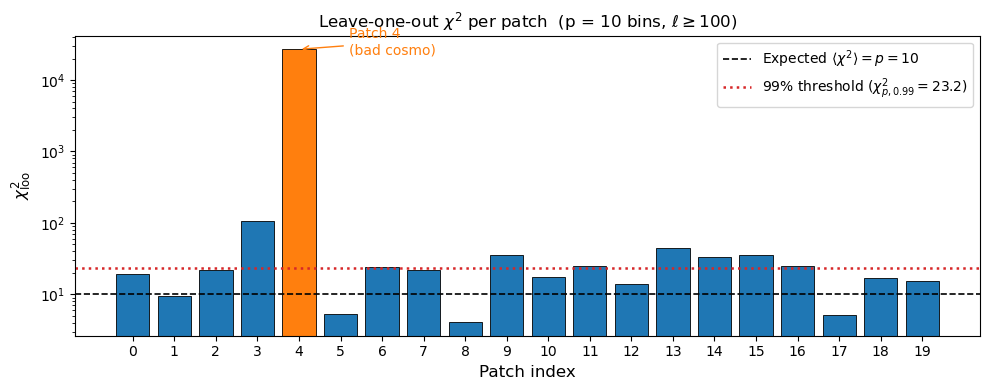

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

colors = ["C1" if k == bad_patch else "C0" for k in range(N)]
ax.bar(range(N), chi2_loo, color=colors, edgecolor="k", linewidth=0.6)

ax.axhline(p,         color="k",  ls="--", lw=1.2,
           label=rf"Expected $\langle\chi^2\rangle = p = {p}$")
ax.axhline(thresh_99, color="C3", ls=":",  lw=1.8,
           label=rf"99% threshold ($\chi^2_{{p,0.99}} = {thresh_99:.1f}$)")

ax.annotate(
    f"Patch {bad_patch}\n(bad cosmo)",
    xy=(bad_patch, chi2_loo[bad_patch]),
    xytext=(bad_patch + 1.2, chi2_loo[bad_patch] * 0.85),
    arrowprops=dict(arrowstyle="->", color="C1"),
    color="C1", fontsize=10,
)

ax.set_xlabel("Patch index", fontsize=12)
ax.set_ylabel(r"$\chi^2_{\rm loo}$", fontsize=12)
ax.set_xticks(range(N))
ax.set_title(rf"Leave-one-out $\chi^2$ per patch  (p = {p} bins, $\ell \geq {lmin}$)", fontsize=12)
ax.set_yscale("log")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fig4_chi2_bar.pdf"), bbox_inches="tight")
plt.show()

In [ ]:
# Sky map coloured by chi2_loo / thresh_99 — values > 1 are outliers
sky_chi2 = np.full(hp.nside2npix(nside), hp.UNSEEN, dtype=np.float64)
for k in range(N):
    sky_chi2[jkmap_patches == k + 1] = chi2_loo[k] / 100

footpix      = np.where(footprint)[0]
vec          = np.mean(np.stack(hp.pix2vec(nside, footpix), axis=1), axis=0)
lon_c, lat_c = hp.vec2ang(vec / np.linalg.norm(vec), lonlat=True)
lon_c, lat_c = float(lon_c), float(lat_c)

hp.mollview(
    sky_chi2,
    rot=(lon_c, lat_c, 0),
    title=r"$\chi^2_{\rm loo}$ / thresh$_{99}$ per patch  (> 1 = outlier)",
    cmap="RdYlGn_r",
    min=0, max=2,
    notext=True,
)
hp.graticule(dpar=5, dmer=5, alpha=0.3)
plt.savefig(os.path.join(PLOT_DIR, "fig5_sky_chi2.pdf"), bbox_inches="tight")
plt.show()

NameError: name 'np' is not defined

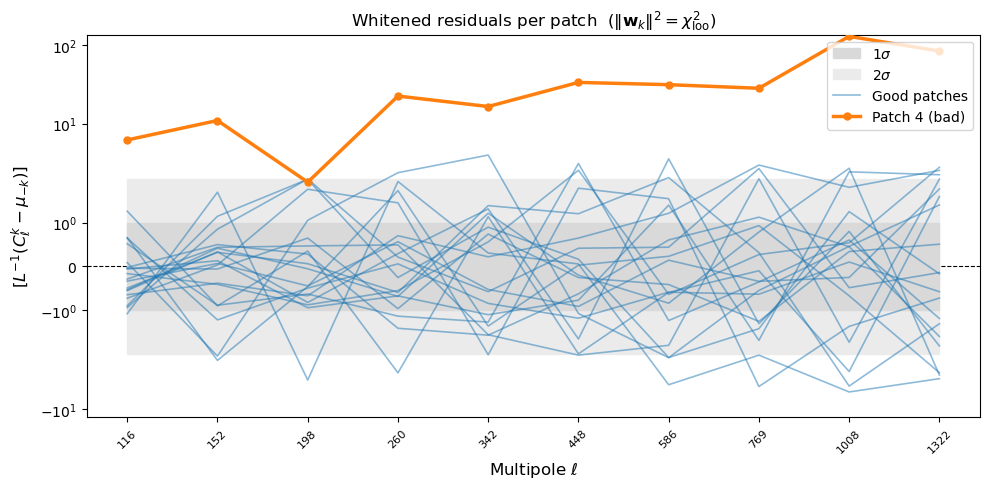

In [ ]:
# ── Whitened residuals: L^{-1} (C_ell^k - mu_{-k}), all patches overplotted ─
# L is the Cholesky factor of cov_loo (cov from the other N-1 patches),
# so each component of the whitened residual is ~N(0,1) under the null
# and ||w_k||^2 = chi2_loo[k].

fig, ax = plt.subplots(figsize=(10, 5))

ax.axhline(0,  color="k",   lw=0.8, ls="--", zorder=0)
ax.fill_between(range(p), -1, 1, color="0.85", zorder=1, label=r"$1\sigma$")
ax.fill_between(range(p), -2, 2, color="0.92", zorder=0, label=r"$2\sigma$")

for k in range(N):
    idx_rest = [j for j in range(N) if j != k]
    cls_rest = cls_chi2[idx_rest]
    mu_loo   = cls_rest.mean(axis=0)
    cov_loo  = np.cov(cls_rest.T)
    L        = np.linalg.cholesky(cov_loo)
    w        = np.linalg.solve(L, cls_chi2[k] - mu_loo)

    if k == bad_patch:
        ax.plot(range(p), w, color="C1", lw=2.5, marker="o", ms=5,
                zorder=5, label=f"Patch {k} (bad)")
    else:
        ax.plot(range(p), w, color="C0", lw=1.2, alpha=0.5,
                zorder=2, label="Good patches" if k == 0 else None)

ax.set_xticks(range(p))
ax.set_xticklabels([f"{l:.0f}" for l in ell_full[chi2_mask]], rotation=45, fontsize=8)
ax.set_xlabel(r"Multipole $\ell$", fontsize=12)
ax.set_ylabel(r"$[L^{-1}(C_\ell^k - \mu_{{-k}})]$", fontsize=12)
ax.set_title(
    r"Whitened residuals per patch  ($\|\mathbf{w}_k\|^2 = \chi^2_{\rm loo}$)",
    fontsize=12,
)
ax.legend(fontsize=10)
ax.set_yscale("symlog", linthresh=2)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fig6_whitened_residuals.pdf"), bbox_inches="tight")
plt.show()
